In [1]:
import pandas as pd

# Load your data
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

# Rename columns for simplicity
df.rename(columns={
    'name': 'Car_Name',
    'year': 'Year',
    'selling_price': 'Selling_Price',
    'km_driven': 'Kms_Driven',
    'fuel': 'Fuel_Type',
    'seller_type': 'Seller_Type',
    'transmission': 'Transmission',
    'owner': 'Owner'
}, inplace=True)

# Drop Car_Name (not useful for prediction)
df.drop('Car_Name', axis=1, inplace=True)

# Clean Kms_Driven (remove commas if any)
df['Kms_Driven'] = df['Kms_Driven'].astype(str).str.replace(',', '').astype(int)

# Convert Owner to numeric categories
df['Owner'] = df['Owner'].replace({
    'First Owner': 0,
    'Second Owner': 1,
    'Third Owner': 2,
    'Fourth & Above Owner': 3,
    'Test Drive Car': 4
}).astype(int)

# Create a new feature: Car Age
df['Car_Age'] = 2025 - df['Year']
df.drop('Year', axis=1, inplace=True)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

C:\Users\PMLS\AppData\Local\Temp\ipykernel_45672\2038515202.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Owner'] = df['Owner'].replace({


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Split features and target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(random_state=150)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model trained successfully!")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Model trained successfully!
Mean Squared Error: 154784772209.79
R² Score: 0.49


Feature Importance:
 Transmission_Manual             0.297245
Kms_Driven                      0.288073
Car_Age                         0.198509
Fuel_Type_Diesel                0.116369
Seller_Type_Individual          0.048764
Fuel_Type_Petrol                0.024740
Owner                           0.020733
Seller_Type_Trustmark Dealer    0.005543
Fuel_Type_LPG                   0.000020
Fuel_Type_Electric              0.000003
dtype: float64


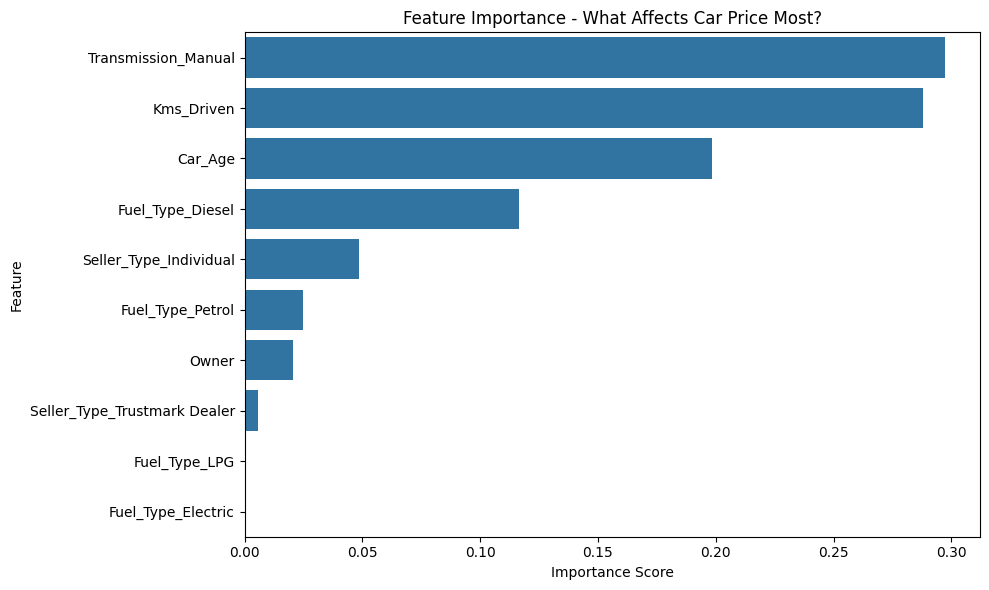

In [3]:
# Show feature importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Print
print("Feature Importance:\n", feature_importance)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title("Feature Importance - What Affects Car Price Most?")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [4]:
print(df.columns)


Index(['Selling_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Electric', 'Fuel_Type_LPG', 'Fuel_Type_Petrol',
       'Seller_Type_Individual', 'Seller_Type_Trustmark Dealer',
       'Transmission_Manual'],
      dtype='object')
